In [2]:
RESP_H5_PATH = r"C:\Users\Padilla-Coreano\Documents\tanish\Resp_h5"
EXCEL_PATH = r"C:\Users\Padilla-Coreano\Documents\tanish\Keypoint RI1+RI2\Excel_Results"
PROCESSED_DATA_PATH = r"C:\Users\Padilla-Coreano\Documents\tanish\Keypoint RI1+RI2\Excel_Results\processed_respiration_data_0.5Hz.pkl"

ORIGINAL_SAMPLING_RATE = 20000
TARGET_SAMPLING_RATE = 100
MIN_SYLLABLE_DURATION = 500

PEAK_MIN_DISTANCE = 0.08
PEAK_PROMINENCE_FACTOR = 0.2

FPS_MAPPING = {
    "RI1_s1_1": 15,
    "RI1_s2_3": 15,
    "RI1_s3_6": 29,
    "RI2_s1_1": 15,
    "RI2_s2_4": 15
}
DEFAULT_FPS = 30

print("Configuration loaded")

Configuration loaded


In [3]:
def detect_breathing_peaks(signal, fs=TARGET_SAMPLING_RATE):
    signal_std = np.std(signal)
    signal_mean = np.mean(signal)
    
    peaks, properties = find_peaks(
        signal,
        distance=int(fs * PEAK_MIN_DISTANCE),
        prominence=signal_std * PEAK_PROMINENCE_FACTOR,
        height=signal_mean
    )
    
    return peaks

def get_video_fps(filename):
    for pattern, fps in FPS_MAPPING.items():
        if pattern in filename:
            return fps
    return DEFAULT_FPS

print("Peak detection functions defined")

Peak detection functions defined


In [4]:
def calculate_respiratory_metrics(peaks, fs=TARGET_SAMPLING_RATE):
    if len(peaks) < 2:
        return np.array([]), np.array([]), np.array([])
    
    peak_times = peaks / fs
    ibi_seconds = np.diff(peak_times)
    breathing_rate_1_over_ibi = 1 / ibi_seconds
    breath_times = peak_times[1:]
    
    return breathing_rate_1_over_ibi, breath_times, ibi_seconds

def create_syllable_bouts(behavior_df, video_fps, min_duration_ms=MIN_SYLLABLE_DURATION):
    behavior_df = behavior_df.copy()
    behavior_df['time_seconds'] = behavior_df['frame_number'] / video_fps
    behavior_df['transition'] = (behavior_df['syllable'] != behavior_df['syllable'].shift()).astype(int)
    behavior_df['bout_group'] = behavior_df['transition'].cumsum()
    
    bouts_list = []
    
    for group_id, group in behavior_df.groupby('bout_group'):
        syllable_id = group['syllable'].iloc[0]
        start_time = group['time_seconds'].min()
        end_time = group['time_seconds'].max()
        duration_ms = (end_time - start_time) * 1000
        
        if duration_ms >= min_duration_ms:
            bout_info = {
                'syllable_id': syllable_id,
                'start_frame': group['frame_number'].min(),
                'end_frame': group['frame_number'].max(),
                'start_time_sec': start_time,
                'end_time_sec': end_time,
                'duration_ms': duration_ms,
                'frame_count': len(group),
                'fps_used': video_fps
            }
            bouts_list.append(bout_info)
    
    return bouts_list

print("Data processing functions defined")

Data processing functions defined


In [5]:
def process_single_session(session_id, respiratory_signal, excel_files):
    print(f"Processing: {session_id}")
    
    signal = respiratory_signal['respiration']
    fs = TARGET_SAMPLING_RATE
    time_vector = np.arange(len(signal)) / fs
    
    peaks = detect_breathing_peaks(signal, fs)
    print(f"  Peaks detected: {len(peaks)}")
    
    if len(peaks) < 2:
        print("  Insufficient peaks - skipping")
        return None
    
    breathing_rates, breath_times, ibi_values = calculate_respiratory_metrics(peaks, fs)
    breathing_rates_bpm = breathing_rates * 60
    
    matching_excel = None
    for excel_file in excel_files:
        session_patterns = ['RI1_s1_1', 'RI1_s1_2', 'RI1_s2_3', 'RI1_s2_4', 
                           'RI1_s3_5', 'RI1_s3_6', 'RI1_s4_7', 'RI1_s4_8', 'RI1_s5_13',
                           'RI2_s1_1', 'RI2_s1_2', 'RI2_s2_3', 'RI2_s2_4', 
                           'RI2_s3_5', 'RI2_s3_6', 'RI2_s4_7', 'RI2_s4_8', 'RI2_s5_13']
        
        if any(pattern in session_id and pattern in excel_file for pattern in session_patterns):
            matching_excel = excel_file
            break
    
    if not matching_excel:
        print("  No matching behavioral file")
        return None
    
    behavior_df = pd.read_excel(matching_excel)
    video_fps = get_video_fps(os.path.basename(matching_excel))
    
    bouts_list = create_syllable_bouts(behavior_df, video_fps)
    
    if not bouts_list:
        print("  No valid syllable bouts")
        return None
    
    processed_bouts = []
    
    for bout in bouts_list:
        bout_start = bout['start_time_sec']
        bout_end = bout['end_time_sec']
        
        time_mask = (time_vector >= bout_start) & (time_vector <= bout_end)
        bout_signal = signal[time_mask]
        
        if len(bout_signal) > 0:
            resp_stats = {
                'mean_resp_signal': np.mean(bout_signal),
                'min_resp_signal': np.min(bout_signal),
                'max_resp_signal': np.max(bout_signal),
                'resp_signal_range': np.max(bout_signal) - np.min(bout_signal)
            }
        else:
            resp_stats = {k: np.nan for k in ['mean_resp_signal', 'min_resp_signal', 
                                            'max_resp_signal', 'resp_signal_range']}
        
        peak_times = peaks / fs
        syllable_peaks = peak_times[(peak_times >= bout_start) & (peak_times <= bout_end)]
        breath_count = len(syllable_peaks)
        
        if len(syllable_peaks) > 1:
            syllable_ibis = np.diff(syllable_peaks)
            mean_ibi = np.mean(syllable_ibis)
            mean_breathing_rate = 1 / mean_ibi
            mean_bpm = mean_breathing_rate * 60
        else:
            mid_time = (bout_start + bout_end) / 2
            if len(breath_times) > 0:
                mean_breathing_rate = np.interp(mid_time, breath_times, breathing_rates)
                mean_bpm = mean_breathing_rate * 60
                mean_ibi = 1 / mean_breathing_rate if mean_breathing_rate > 0 else np.nan
            else:
                mean_breathing_rate = mean_bpm = mean_ibi = np.nan
        
        bout_data = {
            **bout,
            **resp_stats,
            'breath_count': breath_count,
            'mean_1_over_IBI': mean_breathing_rate,
            'mean_breathing_rate_BPM': mean_bpm,
            'mean_IBI_seconds': mean_ibi,
            'video_name': behavior_df['video_name'].iloc[0] if 'video_name' in behavior_df.columns else 'unknown',
            'track_name': behavior_df['track_name'].iloc[0] if 'track_name' in behavior_df.columns else 'track0'
        }
        
        processed_bouts.append(bout_data)
    
    results_df = pd.DataFrame(processed_bouts)
    results_df = results_df.sort_values('start_time_sec').reset_index(drop=True)
    
    print(f"  Processed {len(results_df)} syllable bouts")
    
    return results_df

print("Main analysis function defined")

Main analysis function defined


In [6]:
def run_complete_analysis():
    print("Starting analysis...")
    
    respiratory_data = pd.read_pickle(PROCESSED_DATA_PATH)
    excel_files = glob.glob(os.path.join(EXCEL_PATH, "*track0*.xlsx"))
    
    print(f"Found {len(respiratory_data)} respiratory sessions")
    print(f"Found {len(excel_files)} behavioral files")
    
    all_results = {}
    successful_sessions = 0
    
    for session_id, resp_data in respiratory_data.items():
        try:
            result = process_single_session(session_id, resp_data, excel_files)
            
            if result is not None:
                session_name = session_id.replace('.h5', '')
                output_file = f"CORRECTED_PEAK_COUNT_{session_name}_analysis.xlsx"
                result.to_excel(output_file, index=False)
                print(f"  Saved: {output_file}")
                
                all_results[session_id] = result
                successful_sessions += 1
            
        except Exception as e:
            print(f"  Error processing {session_id}: {str(e)}")
    
    print(f"Analysis complete: {successful_sessions}/{len(respiratory_data)} sessions processed")
    
    return all_results

analysis_results = run_complete_analysis()

Starting analysis...
Found 18 respiratory sessions
Found 17 behavioral files
Processing: RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5
  Peaks detected: 4566
  Processed 303 syllable bouts
  Saved: CORRECTED_PEAK_COUNT_RI1_s1_1_p5_2_nRB6_20250622_143958_merged_analysis.xlsx
Processing: RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5
  Peaks detected: 4495
  Processed 266 syllable bouts
  Saved: CORRECTED_PEAK_COUNT_RI1_s1_2_p5_1_nRB6_20250622_170742_merged_analysis.xlsx
Processing: RI1_s2_3_p5_3_nRB3_20250622_104059_merged.h5
  Peaks detected: 4091
  Processed 504 syllable bouts
  Saved: CORRECTED_PEAK_COUNT_RI1_s2_3_p5_3_nRB3_20250622_104059_merged_analysis.xlsx
Processing: RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5
  Peaks detected: 5100
  Processed 132 syllable bouts
  Saved: CORRECTED_PEAK_COUNT_RI1_s2_4_p5_4_nRB3_20250622_123424_merged_analysis.xlsx
Processing: RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5
  Peaks detected: 4163
  No matching behavioral file
Processing: RI1_s3_6_p5_3

In [8]:
print("Analysis Summary")
print("="*40)

if analysis_results:
    total_sessions = len(analysis_results)
    total_syllables = sum(len(df) for df in analysis_results.values())
    
    all_bouts = pd.concat(analysis_results.values(), ignore_index=True)
    
    print(f"Sessions processed: {total_sessions}")
    print(f"Total syllable bouts: {total_syllables}")
    print(f"Duration range: {all_bouts['duration_ms'].min():.0f} - {all_bouts['duration_ms'].max():.0f} ms")
    print(f"Breathing rate range: {all_bouts['mean_breathing_rate_BPM'].min():.0f} - {all_bouts['mean_breathing_rate_BPM'].max():.0f} BPM")
    print(f"Unique syllables: {all_bouts['syllable_id'].nunique()}")

print("Output files: CORRECTED_PEAK_COUNT_*_analysis.xlsx")
print(f"Completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Analysis Summary
Sessions processed: 17
Total syllable bouts: 4143
Duration range: 500 - 55767 ms
Breathing rate range: 1 - 750 BPM
Unique syllables: 52
Output files: CORRECTED_PEAK_COUNT_*_analysis.xlsx
Completed: 2025-10-28 16:44:57


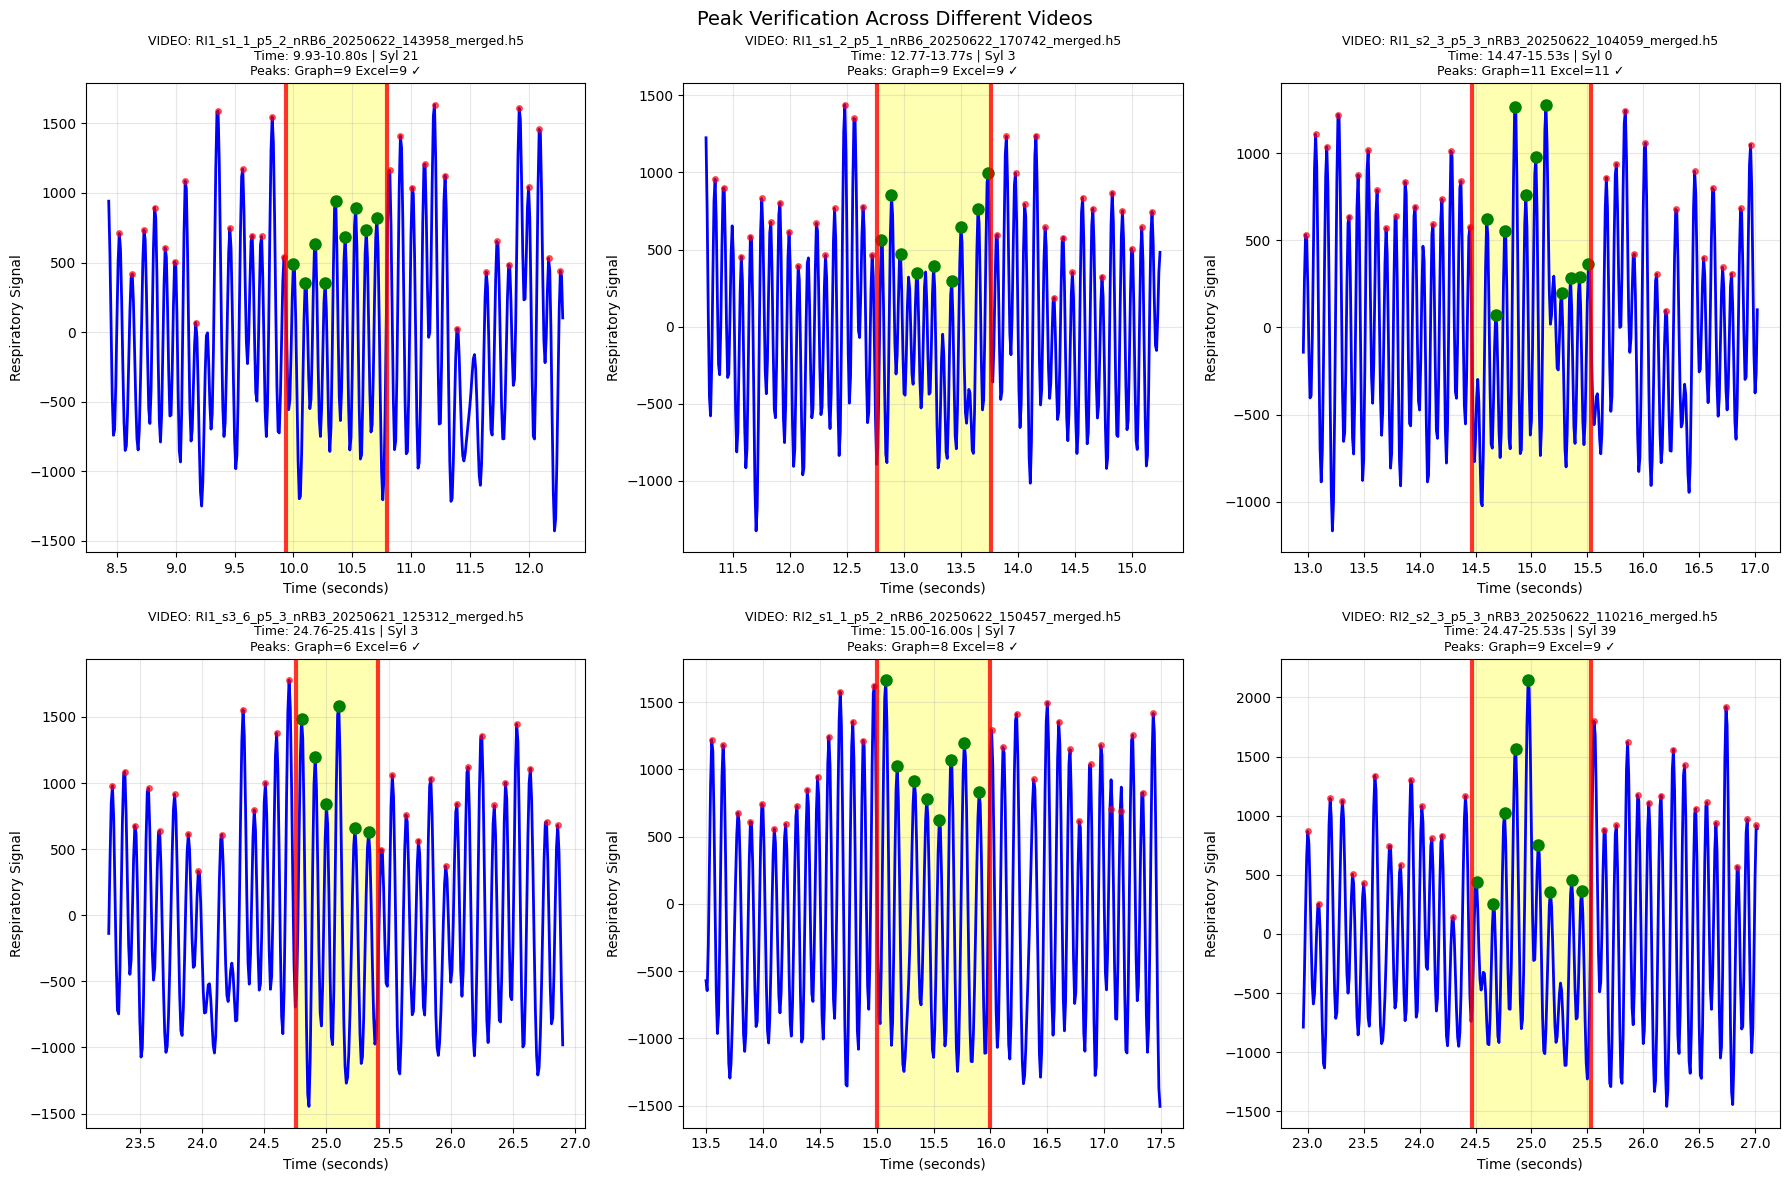

In [9]:
def plot_with_clear_video_info():
    """Plot with clear video names and timing information"""
    
    plot_tests = [
        ("RI1_s1_1", 5),   ("RI1_s1_2", 8),   ("RI1_s2_3", 6),
        ("RI1_s3_6", 10),  ("RI2_s1_1", 7),   ("RI2_s2_3", 9)
    ]
    
    respiratory_data = pd.read_pickle(PROCESSED_DATA_PATH)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for i, (session_pattern, row_idx) in enumerate(plot_tests):
        
        # Find Excel file
        excel_pattern = f"CORRECTED_PEAK_COUNT_*{session_pattern}*_analysis.xlsx"
        excel_files = glob.glob(excel_pattern)
        
        if not excel_files:
            continue
            
        df = pd.read_excel(excel_files[0])
        
        if row_idx >= len(df):
            continue
            
        # Get respiratory data and find original video name
        resp_key = None
        for key in respiratory_data.keys():
            if session_pattern in key:
                resp_key = key
                break
                
        if resp_key is None:
            continue
            
        signal = respiratory_data[resp_key]['respiration']
        fs = TARGET_SAMPLING_RATE
        
        # Get bout info
        bout = df.iloc[row_idx]
        start_time = bout['start_time_sec']
        end_time = bout['end_time_sec']
        
        # Extract original video filename from resp_key
        original_video_name = resp_key  # This is your original h5 filename
        
        # Detect peaks
        peaks = detect_breathing_peaks(signal, fs)
        peak_times = peaks / fs
        
        syllable_peaks = peak_times[(peak_times >= start_time) & (peak_times <= end_time)]
        graph_count = len(syllable_peaks)
        excel_count = bout['breath_count']
        
        # Plot
        context = 1.5
        plot_start = max(0, start_time - context)
        plot_end = min(len(signal)/fs, end_time + context)
        
        i0 = int(plot_start * fs)
        i1 = int(plot_end * fs)
        t_plot = np.arange(i0, i1) / fs
        
        window_peaks = peak_times[(peak_times >= plot_start) & (peak_times <= plot_end)]
        
        ax = axes[i]
        ax.plot(t_plot, signal[i0:i1], 'b-', lw=2)
        ax.plot(window_peaks, signal[(window_peaks * fs).astype(int)], 'ro', ms=4, alpha=0.6)
        ax.plot(syllable_peaks, signal[(syllable_peaks * fs).astype(int)], 'go', ms=8)
        
        ax.axvline(start_time, color='red', linestyle='-', linewidth=3, alpha=0.8)
        ax.axvline(end_time, color='red', linestyle='-', linewidth=3, alpha=0.8)
        ax.axvspan(start_time, end_time, alpha=0.3, color='yellow')
        
        # Clear title with video name and timing
        match_status = "✓" if graph_count == excel_count else "✗"
        ax.set_title(f"VIDEO: {original_video_name}\n"
                    f"Time: {start_time:.2f}-{end_time:.2f}s | Syl {bout['syllable_id']:.0f}\n"
                    f"Peaks: Graph={graph_count} Excel={excel_count} {match_status}", 
                    fontsize=9)
        
        ax.set_xlabel("Time (seconds)", fontsize=10)
        ax.set_ylabel("Respiratory Signal", fontsize=10)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle("Peak Verification Across Different Videos", fontsize=14)
    plt.tight_layout()
    plt.show()

# Run with clear video information
plot_with_clear_video_info()

In [13]:
ri1_syllables = set(combined_df[combined_df['ri_group'] == 'RI1']['syllable_id'].unique())
ri2_syllables = set(combined_df[combined_df['ri_group'] == 'RI2']['syllable_id'].unique())

shared_syllables = ri1_syllables.intersection(ri2_syllables)
ri1_only = ri1_syllables - ri2_syllables  
ri2_only = ri2_syllables - ri1_syllables

print("SYLLABLE DISTRIBUTION")
print("=" * 40)
print(f"Shared syllables: {sorted(list(shared_syllables))}")
print(f"RI1 only: {sorted(list(ri1_only))}")
print(f"RI2 only: {sorted(list(ri2_only))}")

SYLLABLE DISTRIBUTION
Shared syllables: [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 23, 24, 25, 26, 27, 28, 29, 31, 32, 33, 34, 35, 36, 39, 41, 42, 43, 44, 45]
RI1 only: [8, 57, 78, 82, 85]
RI2 only: [12, 22, 40, 46, 51, 52, 58, 87]


In [17]:
# Verification checks
print("VERIFICATION CHECKS:")
print("=" * 30)

# Check 1: Do the numbers add up?
total_unique = len(shared_syllables) + len(ri1_only) + len(ri2_only)
actual_unique = len(combined_df['syllable_id'].unique())
print(f"Math check: {len(shared_syllables)} shared + {len(ri1_only)} RI1-only + {len(ri2_only)} RI2-only = {total_unique}")
print(f"Actual unique syllables: {actual_unique}")
print(f"Numbers match: {total_unique == actual_unique}")

# Check 2: Verify a few shared syllables actually appear in both groups
print("\nSpot check - shared syllables verification:")
for syllable in list(shared_syllables)[:3]:  # Check first 3
    ri1_files = combined_df[(combined_df['syllable_id'] == syllable) & (combined_df['ri_group'] == 'RI1')]['file_name'].unique()
    ri2_files = combined_df[(combined_df['syllable_id'] == syllable) & (combined_df['ri_group'] == 'RI2')]['file_name'].unique()
    print(f"Syllable {syllable}: RI1 files={len(ri1_files)}, RI2 files={len(ri2_files)}")

# Check 3: Verify RI1-only syllables don't appear in RI2
print(f"\nRI1-only check: Checking if any RI1-only syllables appear in RI2...")
ri1_only_in_ri2 = []
for syllable in ri1_only:
    if syllable in ri2_syllables:
        ri1_only_in_ri2.append(syllable)
print(f"RI1-only syllables found in RI2: {ri1_only_in_ri2} (should be empty)")

print(f"\nVerification complete. Results saved to syllable_analysis_complete.xlsx")

VERIFICATION CHECKS:
Math check: 39 shared + 5 RI1-only + 8 RI2-only = 52
Actual unique syllables: 52
Numbers match: True

Spot check - shared syllables verification:
Syllable 0: RI1 files=8, RI2 files=9
Syllable 1: RI1 files=5, RI2 files=3
Syllable 2: RI1 files=6, RI2 files=7

RI1-only check: Checking if any RI1-only syllables appear in RI2...
RI1-only syllables found in RI2: [] (should be empty)

Verification complete. Results saved to syllable_analysis_complete.xlsx


In [ ]:
# Create contingency table for chi-square test of syllable frequency distribution
contingency_data = []
for syllable in sorted(shared_syllables):
    ri1_count = len(combined_df[(combined_df['syllable_id'] == syllable) & (combined_df['ri_group'] == 'RI1')])
    ri2_count = len(combined_df[(combined_df['syllable_id'] == syllable) & (combined_df['ri_group'] == 'RI2')])
    contingency_data.append([ri1_count, ri2_count])

contingency_table = np.array(contingency_data)
chi2_stat, chi2_p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square test for syllable distribution:")
print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"p-value: {chi2_p_value:.6f}")
print(f"Degrees of freedom: {dof}")

Chi-square test for syllable distribution:
Chi-square statistic: 605.0173
p-value: 0.000000
Degrees of freedom: 38


In [ ]:
# Filter syllables to only include those with more than 5 instances in both groups
valid_syllables = []
ttest_results = []

for syllable in sorted(shared_syllables):
    syllable_data = combined_df[combined_df['syllable_id'] == syllable]
    
    ri1_instances = syllable_data[syllable_data['ri_group'] == 'RI1']['mean_1_over_IBI'].dropna()
    ri2_instances = syllable_data[syllable_data['ri_group'] == 'RI2']['mean_1_over_IBI'].dropna()
    
    if len(ri1_instances) > 5 and len(ri2_instances) > 5:
        valid_syllables.append(syllable)
        print(f"Syllable {syllable}: RI1 n={len(ri1_instances)}, RI2 n={len(ri2_instances)} - INCLUDED")
    else:
        print(f"Syllable {syllable}: RI1 n={len(ri1_instances)}, RI2 n={len(ri2_instances)} - EXCLUDED")

print(f"\n{len(valid_syllables)} syllables meet criteria for t-test")

Syllable 0: RI1 n=354, RI2 n=81 - INCLUDED
Syllable 1: RI1 n=16, RI2 n=5 - EXCLUDED
Syllable 2: RI1 n=19, RI2 n=12 - INCLUDED
Syllable 3: RI1 n=651, RI2 n=368 - INCLUDED
Syllable 4: RI1 n=4, RI2 n=8 - EXCLUDED
Syllable 5: RI1 n=41, RI2 n=43 - INCLUDED
Syllable 6: RI1 n=5, RI2 n=7 - EXCLUDED
Syllable 7: RI1 n=130, RI2 n=31 - INCLUDED
Syllable 9: RI1 n=137, RI2 n=52 - INCLUDED
Syllable 10: RI1 n=385, RI2 n=456 - INCLUDED
Syllable 11: RI1 n=116, RI2 n=41 - INCLUDED
Syllable 13: RI1 n=23, RI2 n=7 - INCLUDED
Syllable 14: RI1 n=1, RI2 n=3 - EXCLUDED
Syllable 15: RI1 n=11, RI2 n=7 - INCLUDED
Syllable 16: RI1 n=52, RI2 n=18 - INCLUDED
Syllable 17: RI1 n=2, RI2 n=1 - EXCLUDED
Syllable 18: RI1 n=40, RI2 n=14 - INCLUDED
Syllable 19: RI1 n=36, RI2 n=17 - INCLUDED
Syllable 20: RI1 n=14, RI2 n=7 - INCLUDED
Syllable 21: RI1 n=12, RI2 n=34 - INCLUDED
Syllable 23: RI1 n=11, RI2 n=23 - INCLUDED
Syllable 24: RI1 n=164, RI2 n=25 - INCLUDED
Syllable 25: RI1 n=9, RI2 n=10 - INCLUDED
Syllable 26: RI1 n=10, R

In [ ]:
# Save all results to Excel files and display summary statistics
ttest_df = pd.DataFrame(ttest_results)
ttest_df = ttest_df.sort_values('p_value')
ttest_df.to_excel('syllable_ttest_results.xlsx', index=False)

chi_square_results = pd.DataFrame({
    'Test': ['Chi-square test for syllable distribution'],
    'Chi_square_statistic': [chi2_stat],
    'p_value': [chi2_p_value],
    'degrees_of_freedom': [dof]
})
chi_square_results.to_excel('chi_square_results.xlsx', index=False)

print(f"\nT-TEST SUMMARY:")
print(f"Syllables tested: {len(ttest_df)}")
print(f"Significant (p<0.05): {len(ttest_df[ttest_df['p_value'] < 0.05])}")
print(f"Highly significant (p<0.01): {len(ttest_df[ttest_df['p_value'] < 0.01])}")

print(f"\nCHI-SQUARE SUMMARY:")
print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"p-value: {chi2_p_value:.6f}")

print("\nTop 5 most significant t-test results:")
for i in range(min(5, len(ttest_df))):
    row = ttest_df.iloc[i]
    print(f"Syllable {row['syllable_id']}: difference={row['difference_bps']:.3f} BPS, p={row['p_value']:.6f}")


T-TEST SUMMARY:
Syllables tested: 26
Significant (p<0.05): 5
Highly significant (p<0.01): 3

CHI-SQUARE SUMMARY:
Chi-square statistic: 605.0173
p-value: 0.000000

Top 5 most significant t-test results:
Syllable 31: difference=1.850 BPS, p=0.000001
Syllable 2: difference=-3.218 BPS, p=0.000379
Syllable 43: difference=0.993 BPS, p=0.004196
Syllable 9: difference=-0.932 BPS, p=0.023133
Syllable 32: difference=2.327 BPS, p=0.025166


In [23]:
for syllable in valid_syllables:
    syllable_data = combined_df[combined_df['syllable_id'] == syllable]
    
    ri1_instances = syllable_data[syllable_data['ri_group'] == 'RI1']['mean_1_over_IBI'].dropna()
    ri2_instances = syllable_data[syllable_data['ri_group'] == 'RI2']['mean_1_over_IBI'].dropna()
    
    t_stat, p_value = stats.ttest_ind(ri1_instances, ri2_instances)
    
    ri1_mean = ri1_instances.mean()
    ri1_std = ri1_instances.std()
    ri2_mean = ri2_instances.mean()
    ri2_std = ri2_instances.std()
    
    pooled_std = np.sqrt(((len(ri1_instances) - 1) * ri1_std**2 + 
                         (len(ri2_instances) - 1) * ri2_std**2) / 
                        (len(ri1_instances) + len(ri2_instances) - 2))
    cohens_d = (ri2_mean - ri1_mean) / pooled_std
    
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    
    print(f"Syllable {syllable}: t={t_stat:.3f}, p={p_value:.6f} {significance}")
    
    result = {
        'syllable_id': syllable,
        'ri1_n': len(ri1_instances),
        'ri1_mean_bps': ri1_mean,
        'ri1_std_bps': ri1_std,
        'ri2_n': len(ri2_instances),
        'ri2_mean_bps': ri2_mean,
        'ri2_std_bps': ri2_std,
        'difference_bps': ri2_mean - ri1_mean,
        'percent_change': ((ri2_mean - ri1_mean) / ri1_mean) * 100,
        't_statistic': t_stat,
        'p_value': p_value,
        'cohens_d': cohens_d,
        'significance': significance
    }
    
    ttest_results.append(result)

Syllable 0: t=-0.917, p=0.359815 ns
Syllable 2: t=4.019, p=0.000379 ***
Syllable 3: t=0.717, p=0.473466 ns
Syllable 5: t=1.749, p=0.084088 ns
Syllable 7: t=-0.634, p=0.526798 ns
Syllable 9: t=2.290, p=0.023133 *
Syllable 10: t=-1.688, p=0.091701 ns
Syllable 11: t=-1.286, p=0.200204 ns
Syllable 13: t=0.890, p=0.381153 ns
Syllable 15: t=-0.453, p=0.656576 ns
Syllable 16: t=-1.489, p=0.141113 ns
Syllable 18: t=0.666, p=0.508209 ns
Syllable 19: t=-0.390, p=0.698275 ns
Syllable 20: t=0.707, p=0.487857 ns
Syllable 21: t=1.727, p=0.091262 ns
Syllable 23: t=-0.479, p=0.634940 ns
Syllable 24: t=-0.935, p=0.351053 ns
Syllable 25: t=-1.172, p=0.257324 ns
Syllable 26: t=-1.894, p=0.068667 ns
Syllable 31: t=-5.436, p=0.000001 ***
Syllable 32: t=-2.349, p=0.025166 *
Syllable 35: t=0.277, p=0.783877 ns
Syllable 36: t=0.771, p=0.442772 ns
Syllable 39: t=0.305, p=0.760699 ns
Syllable 41: t=-1.990, p=0.051922 ns
Syllable 43: t=-3.099, p=0.004196 **


In [24]:
ttest_df = pd.DataFrame(ttest_results)
ttest_df = ttest_df.sort_values('p_value')
ttest_df.to_excel('syllable_ttest_results.xlsx', index=False)

chi_square_results = pd.DataFrame({
    'Test': ['Chi-square test for syllable distribution'],
    'Chi_square_statistic': [chi2_stat],
    'p_value': [chi2_p_value],
    'degrees_of_freedom': [dof]
})
chi_square_results.to_excel('chi_square_results.xlsx', index=False)

print(f"\nT-TEST SUMMARY:")
print(f"Syllables tested: {len(ttest_df)}")
print(f"Significant (p<0.05): {len(ttest_df[ttest_df['p_value'] < 0.05])}")
print(f"Highly significant (p<0.01): {len(ttest_df[ttest_df['p_value'] < 0.01])}")

print(f"\nCHI-SQUARE SUMMARY:")
print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"p-value: {chi2_p_value:.6f}")

print("\nTop 5 most significant t-test results:")
for i in range(min(5, len(ttest_df))):
    row = ttest_df.iloc[i]
    print(f"Syllable {row['syllable_id']}: difference={row['difference_bps']:.3f} BPS, p={row['p_value']:.6f}")


T-TEST SUMMARY:
Syllables tested: 26
Significant (p<0.05): 5
Highly significant (p<0.01): 3

CHI-SQUARE SUMMARY:
Chi-square statistic: 605.0173
p-value: 0.000000

Top 5 most significant t-test results:
Syllable 31: difference=1.850 BPS, p=0.000001
Syllable 2: difference=-3.218 BPS, p=0.000379
Syllable 43: difference=0.993 BPS, p=0.004196
Syllable 9: difference=-0.932 BPS, p=0.023133
Syllable 32: difference=2.327 BPS, p=0.025166


In [26]:
from statsmodels.stats.multitest import multipletests

rejected, p_corrected, alpha_sidak, alpha_bonf = multipletests(ttest_df['p_value'], method='fdr_bh')
ttest_df['fdr_corrected_p'] = p_corrected
ttest_df['fdr_significant'] = rejected

print(f"Significant after FDR correction: {sum(ttest_df['fdr_significant'])}")

Significant after FDR correction: 3


In [27]:
ttest_df.to_excel('syllable_ttest_results_with_corrections.xlsx', index=False)

print("Results with corrections saved!")
print("\nComparison:")
print(f"Original significant (p<0.05): {sum(ttest_df['p_value'] < 0.05)}")
print(f"Bonferroni significant: {sum(ttest_df['bonferroni_significant'])}")
print(f"FDR significant: {sum(ttest_df['fdr_significant'])}")

Results with corrections saved!

Comparison:
Original significant (p<0.05): 5
Bonferroni significant: 2
FDR significant: 3


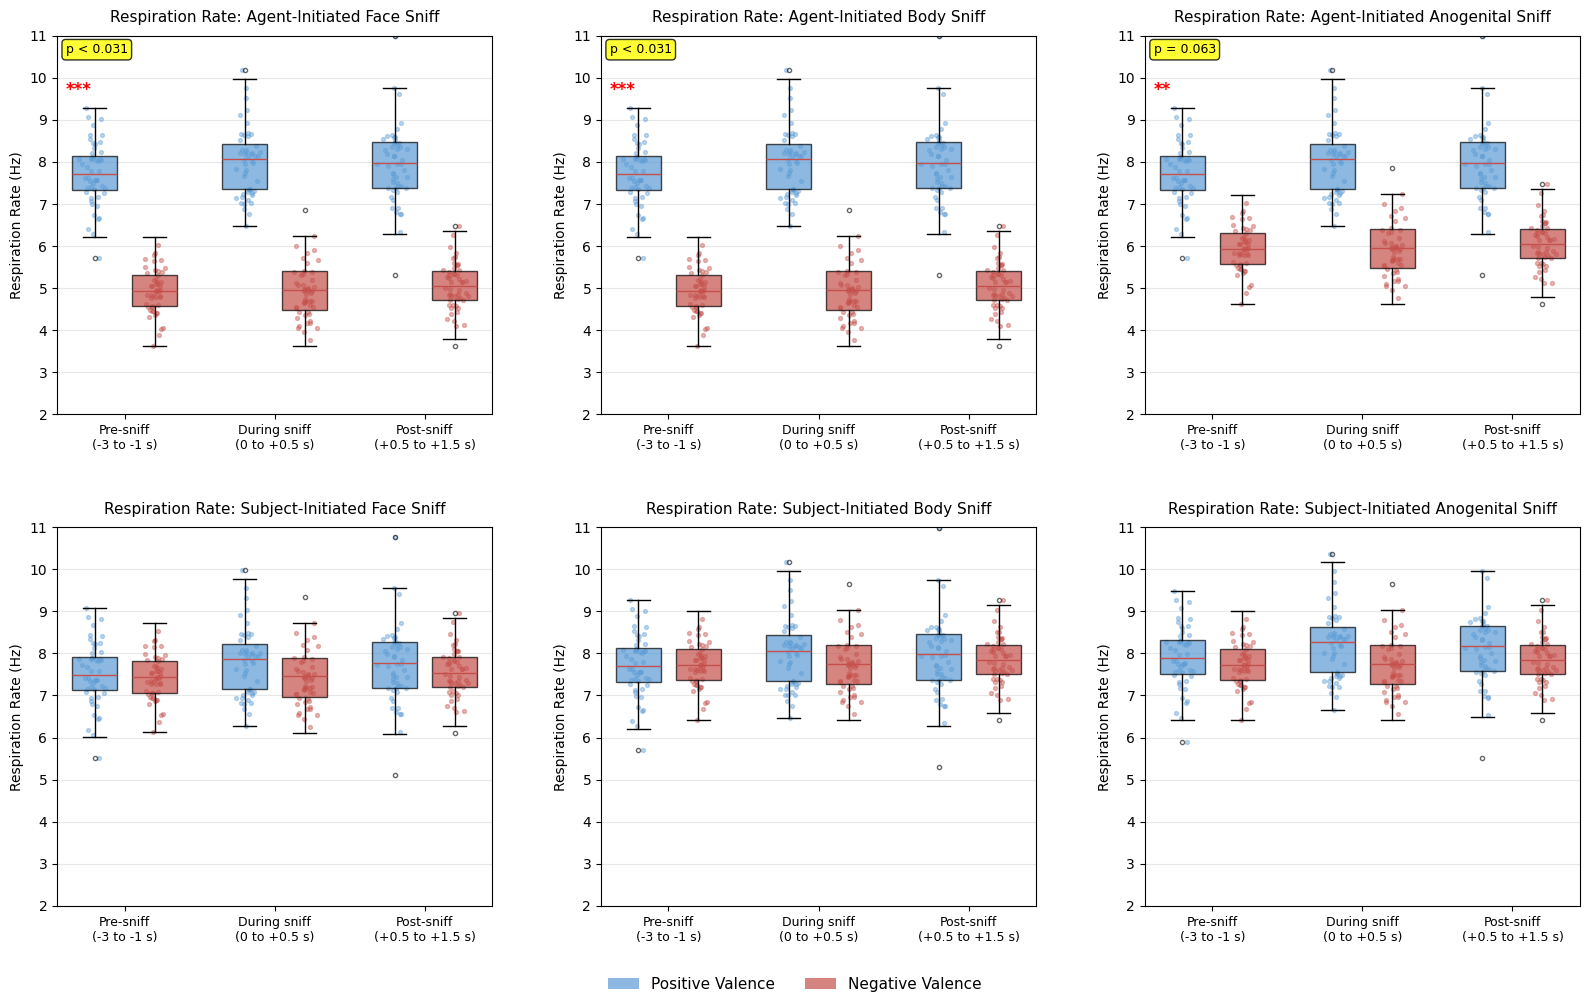

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set style
plt.style.use('default')
sns.set_palette(['#5B9BD5', '#C5504B'])  # Blue and red colors

# Create figure with 2x3 subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('', fontsize=16, y=0.98)

# Define subplot titles and conditions
titles = [
    'Respiration Rate: Agent-Initiated Face Sniff',
    'Respiration Rate: Agent-Initiated Body Sniff', 
    'Respiration Rate: Agent-Initiated Anogenital Sniff',
    'Respiration Rate: Subject-Initiated Face Sniff',
    'Respiration Rate: Subject-Initiated Body Sniff',
    'Respiration Rate: Subject-Initiated Anogenital Sniff'
]

# Time periods for x-axis
time_periods = ['Pre-sniff\n(-3 to -1 s)', 'During sniff\n(0 to +0.5 s)', 'Post-sniff\n(+0.5 to +1.5 s)']

# P-values for significant conditions (adjust based on your actual data)
p_values = ['p < 0.031', 'p < 0.031', 'p = 0.063', None, None, None]

# Function to create sample data for each timepoint
def generate_timepoint_data(base_pos, base_neg, n_points=100):
    """Generate sample data for three timepoints"""
    np.random.seed(42)  # For reproducibility
    
    # Create slight variations across timepoints
    pos_data = {
        'Pre': np.random.normal(base_pos - 0.2, 0.8, n_points),
        'During': np.random.normal(base_pos, 0.8, n_points),
        'Post': np.random.normal(base_pos - 0.1, 0.8, n_points)
    }
    
    neg_data = {
        'Pre': np.random.normal(base_neg - 0.1, 0.6, n_points),
        'During': np.random.normal(base_neg, 0.6, n_points),
        'Post': np.random.normal(base_neg + 0.1, 0.6, n_points)
    }
    
    return pos_data, neg_data

# Base values for each condition (adjust to match your actual data)
base_values = [
    (8.0, 5.0),  # Agent Face
    (8.0, 5.0),  # Agent Body
    (8.0, 6.0),  # Agent Anogenital
    (7.8, 7.5),  # Subject Face
    (8.0, 7.8),  # Subject Body
    (8.2, 7.8)   # Subject Anogenital
]

# Create each subplot
for i, ax in enumerate(axes.flat):
    pos_base, neg_base = base_values[i]
    pos_data, neg_data = generate_timepoint_data(pos_base, neg_base)
    
    # Prepare data for plotting
    plot_data = []
    positions = []
    colors = []
    
    for j, period in enumerate(['Pre', 'During', 'Post']):
        # Positive valence
        plot_data.append(pos_data[period])
        positions.append(j * 2)
        colors.append('#5B9BD5')
        
        # Negative valence  
        plot_data.append(neg_data[period])
        positions.append(j * 2 + 0.8)
        colors.append('#C5504B')
    
    # Create box plots
    box_parts = ax.boxplot(plot_data, positions=positions, widths=0.6, patch_artist=True,
                          showfliers=True, flierprops=dict(marker='o', markersize=3, alpha=0.6))
    
    # Color the boxes
    for patch, color in zip(box_parts['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Add individual points (strip plot style)
    for j, (data, pos, color) in enumerate(zip(plot_data, positions, colors)):
        # Subsample points for cleaner look
        sample_indices = np.random.choice(len(data), min(50, len(data)), replace=False)
        sampled_data = data[sample_indices]
        
        # Add jitter
        jitter = np.random.normal(0, 0.08, len(sampled_data))
        x_pos = np.full(len(sampled_data), pos) + jitter
        
        ax.scatter(x_pos, sampled_data, alpha=0.4, s=8, c=color)
    
    # Customize subplot
    ax.set_title(titles[i], fontsize=11, pad=10)
    ax.set_ylabel('Respiration Rate (Hz)', fontsize=10)
    ax.set_ylim(2, 11)
    
    # Set x-axis
    ax.set_xticks([0.4, 2.4, 4.4])
    ax.set_xticklabels(time_periods, fontsize=9)
    ax.set_xlim(-0.5, 5.3)
    
    # Add significance annotation if applicable
    if p_values[i]:
        ax.text(0.02, 0.98, p_values[i], transform=ax.transAxes, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.8),
                fontsize=9, ha='left', va='top')
        
        # Add significance stars
        stars = '***' if 'p < 0.031' in p_values[i] else '**'
        ax.text(0.02, 0.88, stars, transform=ax.transAxes, 
                fontsize=12, ha='left', va='top', color='red', weight='bold')
    
    # Add grid
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_axisbelow(True)

# Add legend
legend_elements = [
    plt.Rectangle((0,0),1,1, facecolor='#5B9BD5', alpha=0.7, label='Positive Valence'),
    plt.Rectangle((0,0),1,1, facecolor='#C5504B', alpha=0.7, label='Negative Valence')
]
fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.02), 
          ncol=2, fontsize=11, frameon=False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.08, top=0.95, hspace=0.3, wspace=0.25)
plt.show()